# Road Pothole Detection using Gyroscope Anomaly Detection
## Using FB Prophet on Gyroscope (x, y, z) data across all routes (A-F)
### Anomalies are mapped to GPS coordinates and visualized on Leaflet maps

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
import os
import gc
import logging

# Suppress all Prophet / cmdstanpy noise
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Gyroscope + Location Data for All Routes

In [10]:
folders = ['A', 'B', 'C', 'D', 'E', 'F']

def load_route_data(folder):
    """Load gyroscope and location data for a route folder."""
    gyro_path = os.path.join(folder, 'Gyroscope.csv')
    loc_path  = os.path.join(folder, 'Location.csv')

    gyro_df = pd.read_csv(gyro_path,
                           dtype={'x': 'float32', 'y': 'float32',
                                  'z': 'float32', 'seconds_elapsed': 'float32'})
    loc_df  = pd.read_csv(loc_path,
                           dtype={'latitude': 'float64', 'longitude': 'float64',
                                  'altitude': 'float32', 'speed': 'float32'})

    # datetime columns (nanosecond unix timestamps)
    gyro_df['datetime'] = pd.to_datetime(gyro_df['time'], unit='ns')
    loc_df['datetime']  = pd.to_datetime(loc_df['time'],  unit='ns')
    gyro_df.drop('time', axis=1, inplace=True)
    loc_df.drop('time',  axis=1, inplace=True)

    return gyro_df, loc_df

# ── Load everything ──────────────────────────────────────────
all_data = {}
for f in folders:
    gyro, loc = load_route_data(f)
    all_data[f] = {'gyro': gyro, 'location': loc}
    print(f"Route {f}: {len(gyro):,} gyro samples, {len(loc):,} GPS points")

print("\nAll routes loaded.")

Route A: 13,255 gyro samples, 138 GPS points
Route B: 31,531 gyro samples, 327 GPS points
Route C: 12,108 gyro samples, 126 GPS points
Route D: 34,022 gyro samples, 353 GPS points
Route E: 38,639 gyro samples, 400 GPS points
Route F: 19,898 gyro samples, 206 GPS points

All routes loaded.


## 2. Prophet-Based Anomaly Detection (Per-Axis)
Same approach as the original notebook: fit Prophet on each gyroscope axis (x, y, z), flag points where RESIDUAL > mean + 2·std.  
A point is an **anomaly** if ANY axis flags it.

In [11]:
def prophet_anomalies_axis(seconds_elapsed, values, cp_scale=0.2, thresh_k=2):
    """
    Run Prophet on one axis and return boolean anomaly mask.
    Uses seconds_elapsed converted to fake datetime (same trick as original notebook).
    """
    ds = pd.to_datetime(seconds_elapsed, unit='s')
    df = pd.DataFrame({'ds': ds, 'y': values.astype('float64')})

    m = Prophet(daily_seasonality=False,
                yearly_seasonality=False,
                weekly_seasonality=False,
                changepoint_prior_scale=cp_scale,
                uncertainty_samples=0)
    m.fit(df)
    fc = m.predict(df)

    error = np.abs(df['y'].values - fc['yhat'].values)
    threshold = error.mean() + thresh_k * error.std()
    anomalies = error > threshold

    del m, fc
    gc.collect()
    return anomalies, error


def get_anomaly_segments(time_arr, anomalies):
    """Return list of (start_sec, end_sec, start_idx, end_idx) tuples."""
    segments = []
    in_seg = False
    for i, (t, a) in enumerate(zip(time_arr, anomalies)):
        if a and not in_seg:
            in_seg = True
            s_t, s_i = t, i
        elif not a and in_seg:
            in_seg = False
            segments.append({'start': s_t, 'end': t, 'si': s_i, 'ei': i})
    if in_seg:
        segments.append({'start': s_t, 'end': time_arr.iloc[-1],
                         'si': s_i, 'ei': len(time_arr) - 1})
    return segments

print("Functions ready.")

Functions ready.


## 3. Run Anomaly Detection on All Routes

In [12]:
results = {}

for folder in folders:
    print(f"\n{'='*55}  Route {folder}  {'='*55}")
    g = all_data[folder]['gyro']
    t = g['seconds_elapsed']

    anom_x, err_x = prophet_anomalies_axis(t, g['x'])
    anom_y, err_y = prophet_anomalies_axis(t, g['y'])
    anom_z, err_z = prophet_anomalies_axis(t, g['z'])

    # Anomaly if ANY axis flags it (same as original notebook logic)
    combined = anom_x | anom_y | anom_z
    segs = get_anomaly_segments(t, combined)

    results[folder] = {
        'anom_x': anom_x, 'anom_y': anom_y, 'anom_z': anom_z,
        'combined': combined, 'segments': segs,
    }

    n_pts = int(combined.sum())
    print(f"  Anomalous points : {n_pts} / {len(g)}  ({100*n_pts/len(g):.2f}%)")
    print(f"  Anomaly segments : {len(segs)}")
    gc.collect()

print("\n" + "="*60)
print("Detection done for all routes!")
print("="*60)


=======================================================  Route A  =======================================================
  Anomalous points : 851 / 13255  (6.42%)
  Anomaly segments : 282

=======================================================  Route B  =======================================================
  Anomalous points : 2746 / 31531  (8.71%)
  Anomaly segments : 576

=======================================================  Route C  =======================================================
  Anomalous points : 512 / 12108  (4.23%)
  Anomaly segments : 159

=======================================================  Route D  =======================================================
  Anomalous points : 1254 / 34022  (3.69%)
  Anomaly segments : 330

=======================================================  Route E  =======================================================
  Anomalous points : 2143 / 38639  (5.55%)
  Anomaly segments : 317

==============================================

## 4. Plot Gyroscope Anomalies per Route (x, y, z axes)
Same style as the original notebook — magenta shaded regions = anomalies

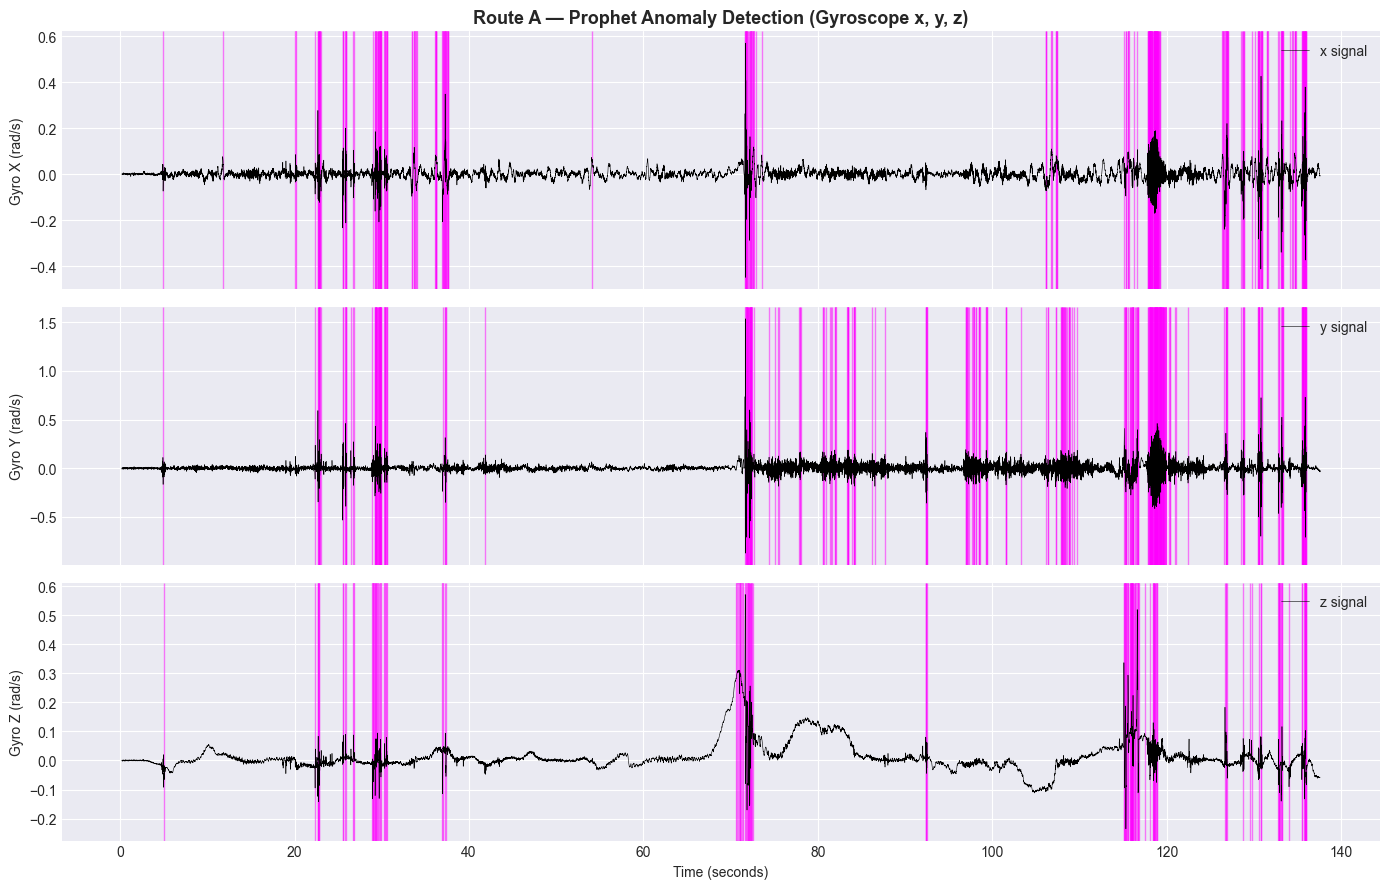

Saved: gyro_anomaly_route_A.png



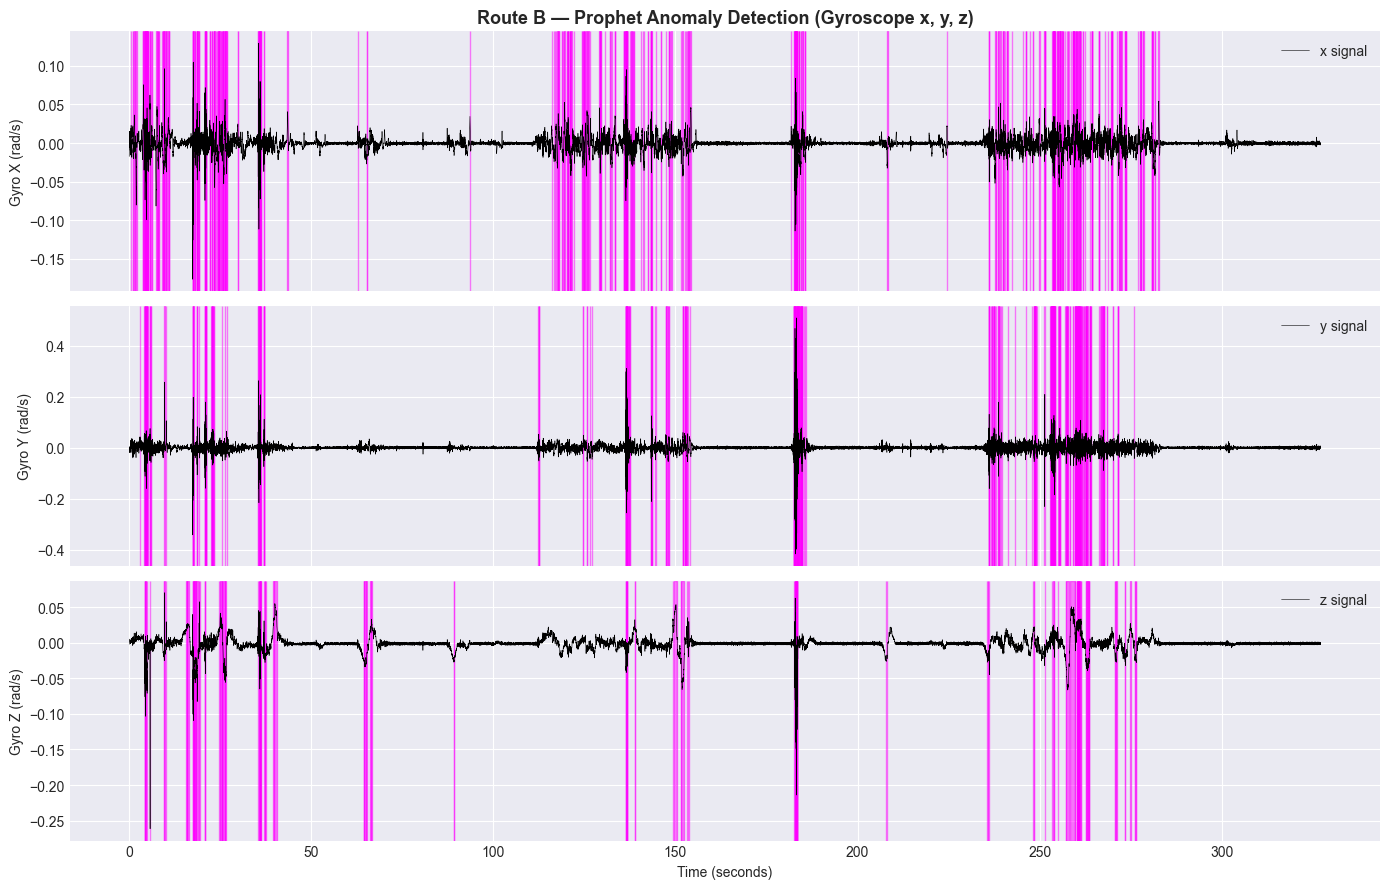

Saved: gyro_anomaly_route_B.png



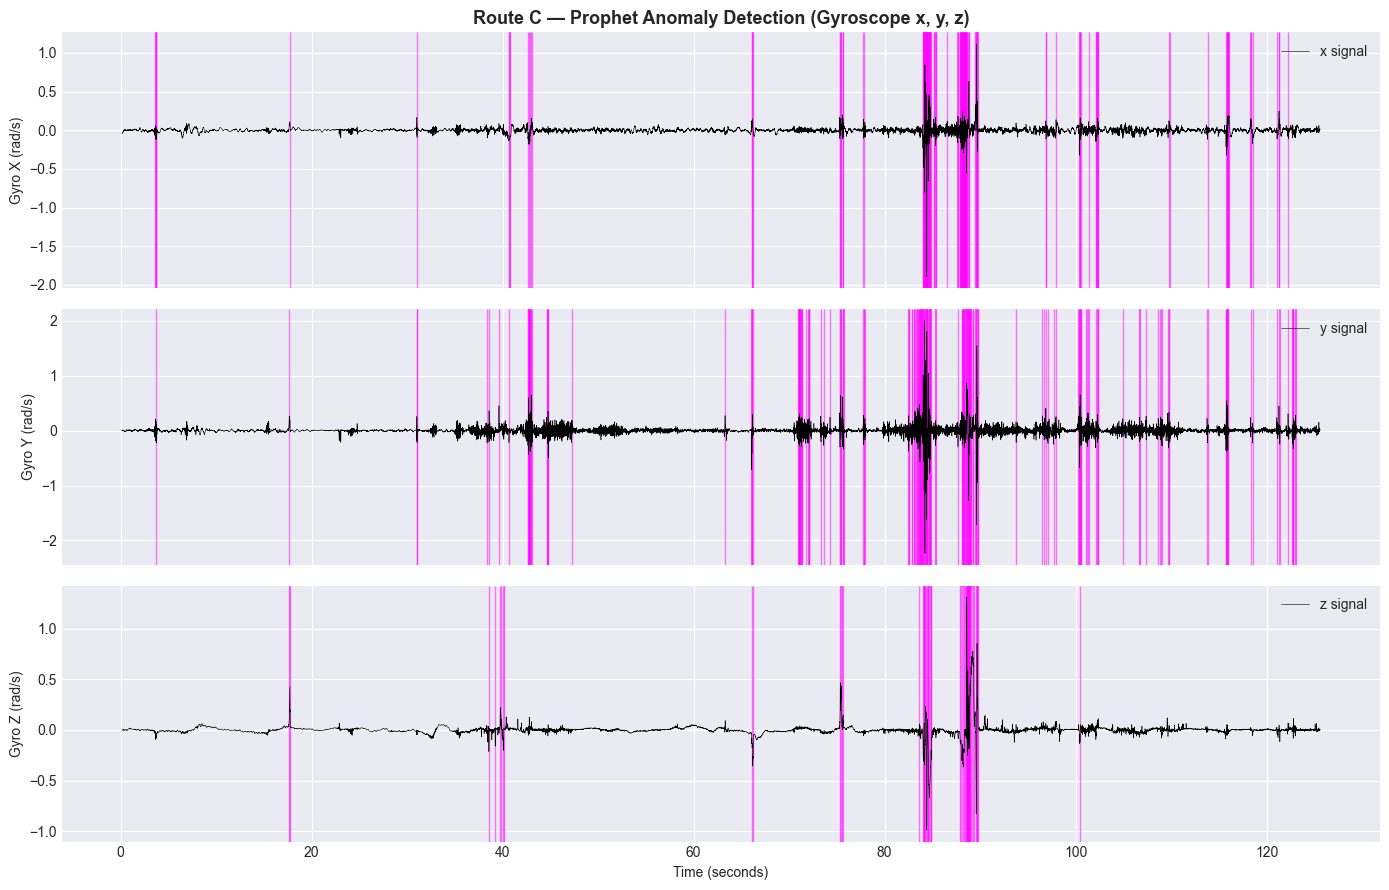

Saved: gyro_anomaly_route_C.png



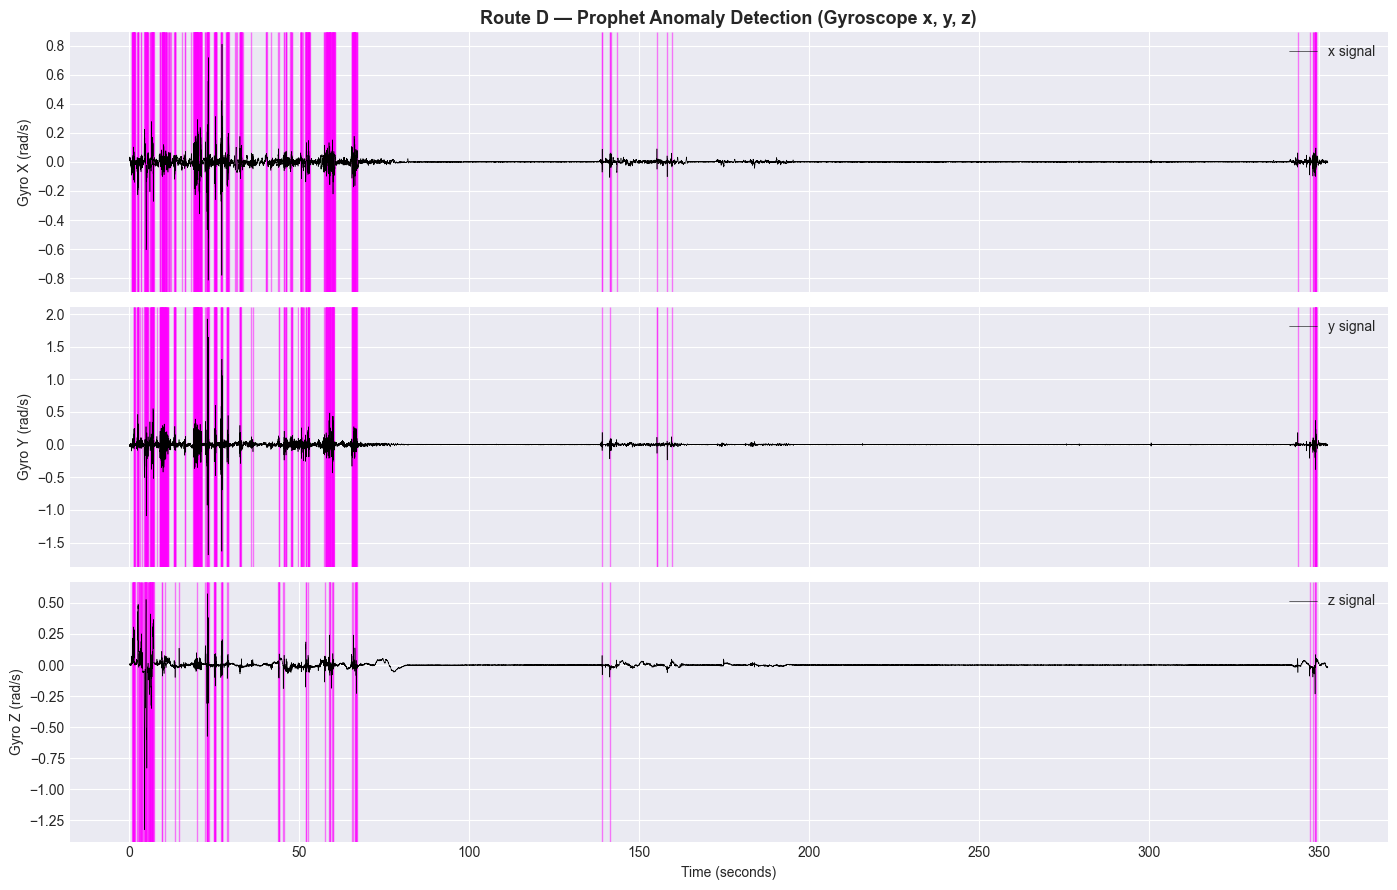

Saved: gyro_anomaly_route_D.png



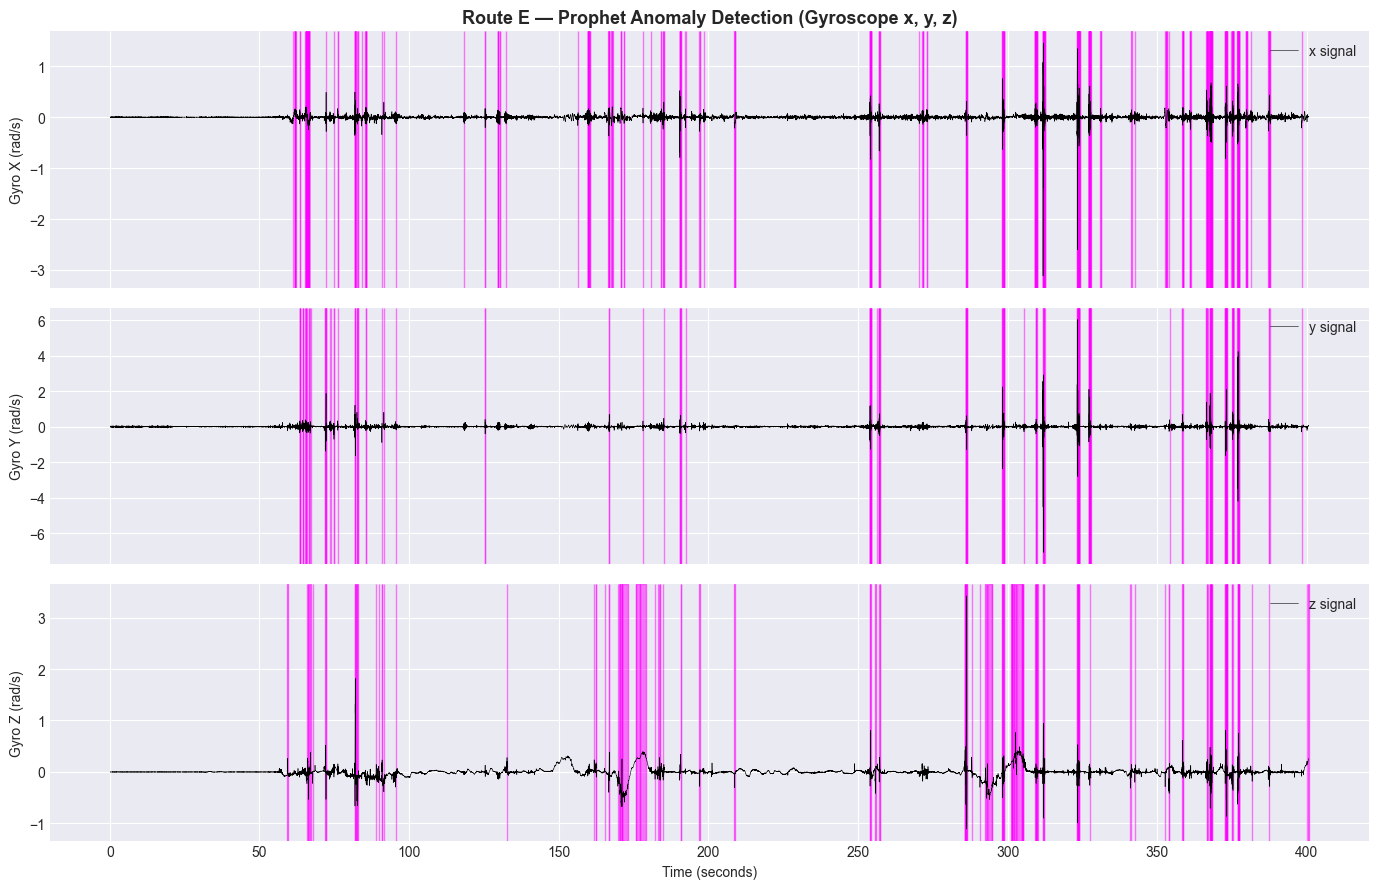

Saved: gyro_anomaly_route_E.png



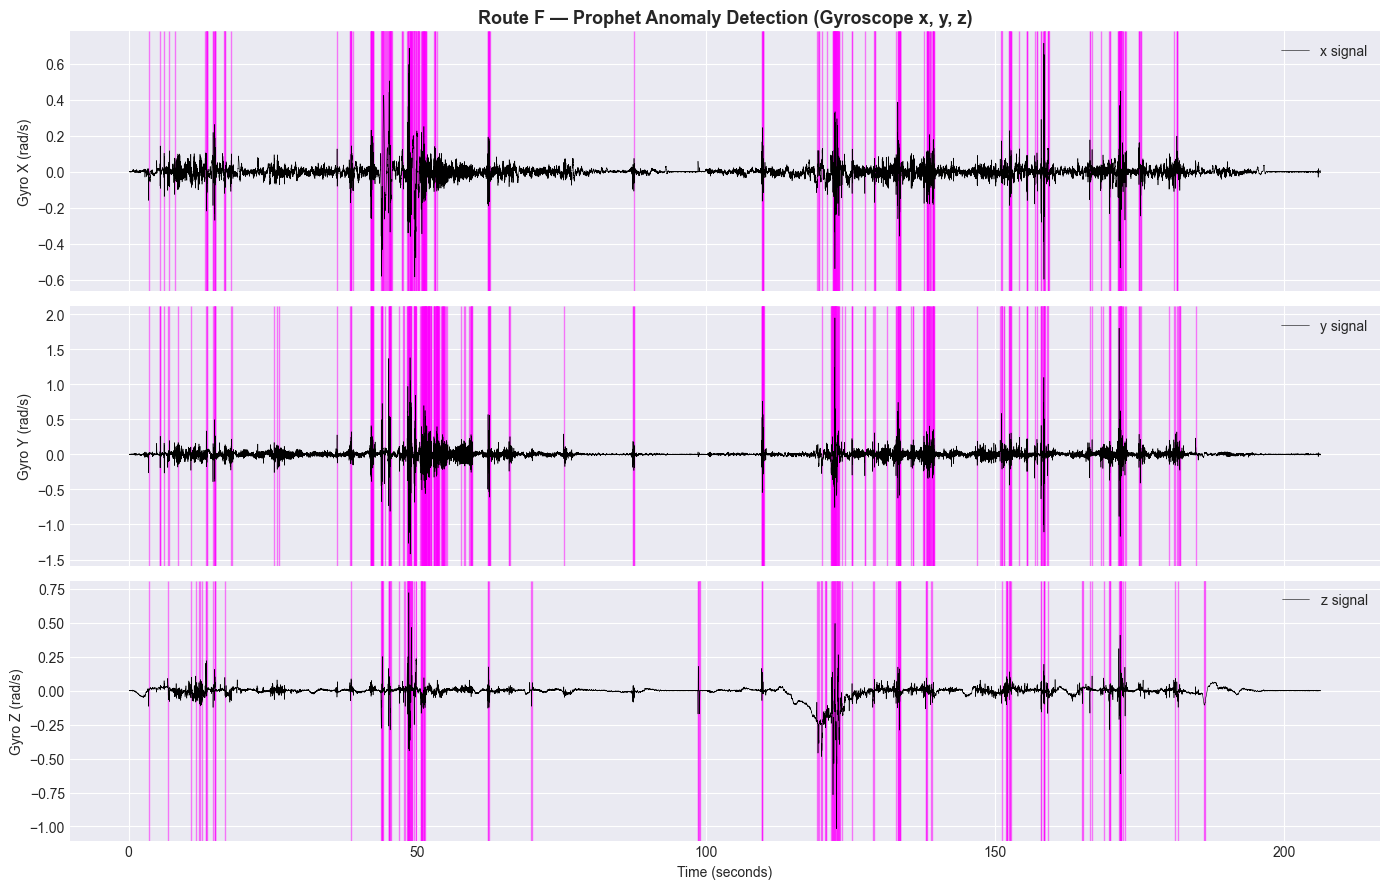

Saved: gyro_anomaly_route_F.png



In [13]:
for folder in folders:
    g   = all_data[folder]['gyro']
    r   = results[folder]
    t   = g['seconds_elapsed']
    segs_x = get_anomaly_segments(t, r['anom_x'])
    segs_y = get_anomaly_segments(t, r['anom_y'])
    segs_z = get_anomaly_segments(t, r['anom_z'])

    fig, axs = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    # X axis
    axs[0].plot(t, g['x'], color='black', linewidth=0.4, label='x signal')
    for s in segs_x:
        axs[0].axvspan(s['start'], s['end'], color='magenta', alpha=0.5)
    axs[0].set_ylabel('Gyro X (rad/s)')
    axs[0].set_title(f'Route {folder} — Prophet Anomaly Detection (Gyroscope x, y, z)',
                      fontsize=13, fontweight='bold')
    axs[0].legend(loc='upper right')

    # Y axis
    axs[1].plot(t, g['y'], color='black', linewidth=0.4, label='y signal')
    for s in segs_y:
        axs[1].axvspan(s['start'], s['end'], color='magenta', alpha=0.5)
    axs[1].set_ylabel('Gyro Y (rad/s)')
    axs[1].legend(loc='upper right')

    # Z axis
    axs[2].plot(t, g['z'], color='black', linewidth=0.4, label='z signal')
    for s in segs_z:
        axs[2].axvspan(s['start'], s['end'], color='magenta', alpha=0.5)
    axs[2].set_ylabel('Gyro Z (rad/s)')
    axs[2].set_xlabel('Time (seconds)')
    axs[2].legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(f'gyro_anomaly_route_{folder}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: gyro_anomaly_route_{folder}.png\n")

## 5. Map Anomaly Segments → GPS Coordinates

In [14]:
def map_segments_to_gps(gyro_df, loc_df, segments):
    """For each anomaly segment, find the closest GPS point by time."""
    rows = []
    for seg in segments:
        mid_sec = (seg['start'] + seg['end']) / 2.0

        # closest GPS point by seconds_elapsed
        idx = (loc_df['seconds_elapsed'] - mid_sec).abs().idxmin()
        loc = loc_df.loc[idx]

        # severity: max absolute gyro reading in the segment
        seg_data = gyro_df.iloc[seg['si']:seg['ei']+1]
        max_gyro = np.sqrt(seg_data['x']**2 + seg_data['y']**2 + seg_data['z']**2).max()

        rows.append({
            'start_sec': seg['start'],
            'end_sec':   seg['end'],
            'duration':  seg['end'] - seg['start'],
            'latitude':  loc['latitude'],
            'longitude': loc['longitude'],
            'speed':     loc['speed'],
            'max_gyro':  float(max_gyro),
            'severity':  float(max_gyro * (seg['end'] - seg['start'])),
        })
    return pd.DataFrame(rows)


all_gps = {}
for folder in folders:
    segs = results[folder]['segments']
    if len(segs) == 0:
        print(f"Route {folder}: no anomalies")
        all_gps[folder] = pd.DataFrame()
        continue
    gps_df = map_segments_to_gps(all_data[folder]['gyro'],
                                  all_data[folder]['location'], segs)
    gps_df['route'] = folder
    all_gps[folder] = gps_df
    print(f"Route {folder}: {len(gps_df)} pothole candidates mapped to GPS")

# Combine
dfs = [d for d in all_gps.values() if len(d) > 0]
combined_gps = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"\nTotal pothole candidates across all routes: {len(combined_gps)}")

Route A: 282 pothole candidates mapped to GPS
Route B: 576 pothole candidates mapped to GPS
Route C: 159 pothole candidates mapped to GPS
Route D: 330 pothole candidates mapped to GPS
Route E: 317 pothole candidates mapped to GPS
Route F: 330 pothole candidates mapped to GPS

Total pothole candidates across all routes: 1994


## 6. Summary & Export CSV

In [15]:
if len(combined_gps) > 0:
    print("="*70)
    print("POTHOLE DETECTION SUMMARY")
    print("="*70)
    for folder in folders:
        df = all_gps[folder]
        if len(df) == 0:
            print(f"\nRoute {folder}: 0 candidates")
            continue
        print(f"\nRoute {folder}: {len(df)} candidates")
        print(f"  Max severity : {df['severity'].max():.4f}")
        print(f"  Mean severity: {df['severity'].mean():.4f}")
        top = df.nlargest(3, 'severity')
        for i, (_, row) in enumerate(top.iterrows(), 1):
            print(f"  #{i}  lat={row['latitude']:.6f}  lon={row['longitude']:.6f}  sev={row['severity']:.4f}")

    print(f"\n{'='*70}")
    print(f"Total candidates: {len(combined_gps)}")
    worst = combined_gps.nlargest(1, 'severity').iloc[0]
    print(f"Most severe: Route {worst['route']}  "
          f"({worst['latitude']:.6f}, {worst['longitude']:.6f})  "
          f"severity={worst['severity']:.4f}")

    # Export
    combined_gps.to_csv('pothole_candidates_all_routes.csv', index=False)
    print("\nExported → pothole_candidates_all_routes.csv")
    display(combined_gps.head(10))
else:
    print("No anomalies detected in any route.")

POTHOLE DETECTION SUMMARY

Route A: 282 candidates
  Max severity : 0.5334
  Mean severity: 0.0115
  #1  lat=30.651298  lon=76.743437  sev=0.5334
  #2  lat=30.653491  lon=76.741825  sev=0.2227
  #3  lat=30.651253  lon=76.743420  sev=0.1360

Route B: 576 candidates
  Max severity : 0.1242
  Mean severity: 0.0041
  #1  lat=30.658991  lon=76.736970  sev=0.1242
  #2  lat=30.661633  lon=76.735140  sev=0.1089
  #3  lat=30.660906  lon=76.735633  sev=0.0923

Route C: 159 candidates
  Max severity : 0.9988
  Mean severity: 0.0270
  #1  lat=30.666669  lon=76.731231  sev=0.9988
  #2  lat=30.667005  lon=76.730969  sev=0.5882
  #3  lat=30.667086  lon=76.730908  sev=0.5773

Route D: 330 candidates
  Max severity : 0.5128
  Mean severity: 0.0162
  #1  lat=30.673100  lon=76.726341  sev=0.5128
  #2  lat=30.674259  lon=76.725416  sev=0.4296
  #3  lat=30.674510  lon=76.725205  sev=0.3754

Route E: 317 candidates
  Max severity : 3.2399
  Mean severity: 0.0665
  #1  lat=30.699521  lon=76.708661  sev=3.239

,start_sec,end_sec,duration,latitude,longitude,speed,max_gyro,severity,route
0,4.925289,4.935642,0.010353,30.648830,76.739272,0.45,0.182004,0.001884,A
1,4.997783,5.008153,0.010370,30.648836,76.739284,1.47,0.098005,0.001016,A
2,11.750476,11.781547,0.031071,30.648925,76.739470,4.11,0.079422,0.002468,A
3,20.098143,20.108500,0.010357,30.649194,76.739926,6.95,0.149667,0.001550,A
4,22.355949,22.376663,0.020714,30.649269,76.740056,7.93,0.248673,0.005151,A
5,22.656301,22.770227,0.113926,30.649269,76.740056,7.93,0.653823,0.074487,A
6,22.780584,22.790941,0.010357,30.649269,76.740056,7.93,0.190976,0.001978,A
7,22.801298,22.822012,0.020714,30.649269,76.740056,7.93,0.229135,0.004746,A
8,22.832369,22.863440,0.031071,30.649269,76.740056,7.93,0.312518,0.009710,A
9,22.894510,22.904867,0.010357,30.649269,76.740056,7.93,0.128134,0.001327,A


## 7. Interactive Leaflet Map (Folium)
Plots the route path and highlights pothole candidates with red markers sized by severity.  
Install folium if needed: `pip install folium`

In [16]:
import folium
from folium.plugins import MarkerCluster

if len(combined_gps) == 0:
    print("Nothing to map.")
else:
    # Centre the map on the mean of all anomaly locations
    centre_lat = combined_gps['latitude'].mean()
    centre_lon = combined_gps['longitude'].mean()

    m = folium.Map(location=[centre_lat, centre_lon], zoom_start=15,
                   tiles='OpenStreetMap')

    # Colour palette per route
    route_colors = {'A': 'red', 'B': 'blue', 'C': 'green',
                    'D': 'orange', 'E': 'purple', 'F': 'darkred'}

    # Draw each route path
    for folder in folders:
        loc = all_data[folder]['location']
        coords = list(zip(loc['latitude'], loc['longitude']))
        folium.PolyLine(coords, color=route_colors.get(folder, 'gray'),
                        weight=3, opacity=0.6,
                        tooltip=f'Route {folder}').add_to(m)

    # Add pothole markers (clustered)
    cluster = MarkerCluster(name='Pothole Candidates').add_to(m)
    for _, row in combined_gps.iterrows():
        sev = row['severity']
        # Marker radius proportional to severity (clamped)
        radius = max(5, min(20, sev * 50))
        popup_text = (f"<b>Route {row['route']}</b><br>"
                      f"Severity: {sev:.4f}<br>"
                      f"Max Gyro: {row['max_gyro']:.4f} rad/s<br>"
                      f"Duration: {row['duration']:.3f}s<br>"
                      f"Speed: {row['speed']:.1f} m/s<br>"
                      f"<a href='https://www.google.com/maps?q={row['latitude']},{row['longitude']}' "
                      f"target='_blank'>Open in Google Maps</a>")

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=route_colors.get(row['route'], 'red'),
            fill=True, fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"Route {row['route']} | sev={sev:.3f}"
        ).add_to(cluster)

    folium.LayerControl().add_to(m)

    # Save standalone HTML
    m.save('pothole_map.html')
    print("Saved interactive map → pothole_map.html")
    m

Saved interactive map → pothole_map.html
